In [73]:
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [74]:
def load_sachs_9_stimulations(data_dir: Path = "./data"):
    """
    Загрузка и объединение 9 стимуляций как в статье Khondker et al.
    """
    all_data = []
    simulation_ids = []

    # Файлы в порядке, указанном в статье
    files = [
        '1. cd3cd28.xls',           # simulation 1
        '2. cd3cd28icam2.xls',      # simulation 2
        '3. cd3cd28+aktinhib.xls',  # simulation 3
        '4. cd3cd28+g0076.xls',     # simulation 4
        '5. cd3cd28+psitect.xls',   # simulation 5
        '6. cd3cd28+u0126.xls',     # simulation 6
        '7. cd3cd28+ly.xls',        # simulation 7
        '8. pma.xls',               # simulation 8
        '9. b2camp.xls'             # simulation 9
    ]

    proteins = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

    for sim_id, fname in enumerate(files, 1):
        filepath = Path(data_dir) / fname
        if filepath.exists():
            # Загрузка Excel файла
            df = pd.read_excel(filepath)
            df.columns = proteins

            # Предполагается, что данные: 11 колонок (белки) x N строк (клетки)
            df.columns = proteins
            all_data.append(df)
            simulation_ids.extend([sim_id] * len(df))
            print(f"Loaded {fname}: {len(df)} cells")
        else:
            print(f"File not found: {filepath}")

    if all_data:
        combined = pd.concat(all_data, ignore_index=True)
        return combined, np.array(simulation_ids)
    else:
        return None, None

data, simulation_ids = load_sachs_9_stimulations()

Loaded 1. cd3cd28.xls: 853 cells
Loaded 2. cd3cd28icam2.xls: 902 cells
Loaded 3. cd3cd28+aktinhib.xls: 911 cells
Loaded 4. cd3cd28+g0076.xls: 723 cells
Loaded 5. cd3cd28+psitect.xls: 810 cells
Loaded 6. cd3cd28+u0126.xls: 799 cells
Loaded 7. cd3cd28+ly.xls: 848 cells
Loaded 8. pma.xls: 913 cells
Loaded 9. b2camp.xls: 707 cells


In [75]:
def preprocess_sachs_data(data: pd.DataFrame, simulation_ids: np.ndarray) -> np.ndarray:
    """
    Предобработка данных
    """
    d = data.shape[1]  # 11 белков
    n_simulations = len(np.unique(simulation_ids))  # 9

    # 1. Логарифмическое преобразование (как в оригинальной статье Sachs)
    data_log = np.log1p(data.values)  # log(1 + x) для избежания log(0)

    # 2. Стандартизация каждого белка (fixed effect of protein)
    scaler = StandardScaler()
    data_std = scaler.fit_transform(data_log)

    # 3. Коррекция на эффект симуляции (random simulation effect)
    data_adjusted = data_std.copy()
    simulation_effects = []

    for sim_id in range(1, n_simulations + 1):
        mask = simulation_ids == sim_id
        if mask.any():
            # Вычитаем среднее по каждой стимуляции
            sim_mean = data_std[mask].mean(axis=0)
            data_adjusted[mask] -= sim_mean
            simulation_effects.append(sim_mean)

    # 4. Финальная стандартизация
    final_scaler = StandardScaler()
    data_final = final_scaler.fit_transform(data_adjusted)

    print(f"Shape after preprocessing: {data_final.shape}")
    print(f"Mean: {data_final.mean():.6f}, Std: {data_final.std():.6f}")

    return data_final, simulation_effects

# Применяем
data_preprocessed, sim_effects = preprocess_sachs_data(data, simulation_ids)

Shape after preprocessing: (7466, 11)
Mean: -0.000000, Std: 1.000000


In [76]:
data_preprocessed

array([[-0.79620982, -0.88073866, -0.80448679, ...,  0.49708635,
         0.45844072,  0.58374223],
       [-0.40334601, -0.5758853 , -0.35259332, ..., -1.33712978,
        -0.63996456,  1.07752111],
       [ 0.24702326,  0.80524266, -0.11497406, ...,  0.01420786,
         0.0791249 , -0.22808392],
       ...,
       [-0.21749337,  0.91900944, -0.0871972 , ..., -0.39736543,
        -1.74685037,  0.01898557],
       [ 0.04858875,  1.48643385, -1.69475517, ...,  3.65115984,
         5.33889467,  0.17927745],
       [-0.11289982, -0.54689924, -1.38239187, ..., -0.39736543,
        -2.10960494, -0.12630707]])

In [77]:
class BCLASSO:
    """
    Bayesian Covariance Lasso (BCLASSO) по статье Khondker et al. (2013)
    Исправленная версия: фиксированные V_k, правильное обновление rho,
    адаптация предложения только на этапе burn-in.
    """

    def __init__(self, rng: np.random.Generator = None, a0: float = 1.0, b0: float = 1.0):
        """
        a0, b0 – гиперпараметры гамма-приора для rho: rho ~ Gamma(a0, b0)
        (В Примере 1 из статьи используется a0=1, b0=1).
        """
        self.rng = rng if rng else np.random.default_rng(42)
        self.a0 = a0
        self.b0 = b0

    def _compute_proposal_covariances(self, Q, n, scale):
        """
        Предварительное вычисление ковариационных матриц предложения V_k
        на основе фиксированной точечной оценки Q.
        """
        d = Q.shape[0]
        V_props = []
        for k in range(d):
            idx = np.arange(d) != k
            Q_kk = Q[k, k]
            q_k = Q[idx, k]
            Q_mkk_inv = np.linalg.inv(Q[idx][:, idx])

            # Вычисление D_k и его производных
            D_k = Q_kk - q_k @ Q_mkk_inv @ q_k
            if D_k <= 1e-10:
                D_k = 1e-5 # Для вычислительной стабильности

            D1 = -2 * Q_mkk_inv @ q_k
            D2 = -2 * Q_mkk_inv

            # Вычисление Гессиана H = -0.5 * n * D_k^{-1} * (D_k^{-1} D1 D1^T + D2)
            term = np.outer(D1, D1) / D_k
            H = -0.5 * n * (1 / D_k) * (term + D2)

            # Ковариация - это масштабированный обратный отрицательный Гессиан
            try:
                V_k = np.linalg.inv(-H) * scale
            except np.linalg.LinAlgError:
                V_k = np.eye(d - 1) * 0.01 * scale

            V_props.append(V_k)
        return V_props

    def fit(self, Y: np.ndarray, rho: float = None,
            n_iter: int = 100000, n_burn: int = 20000, nthin: int = 1,
            adaptive: bool = True, target_accept: float = 0.25,
            m_try: int = 5, update_rho: bool = True):
        """
        Y : (n, d) – данные (центрированные)
        """
        n, d = Y.shape
        S = np.cov(Y.T, bias=True)   # S = (1/n)*Y^T Y

        # 1. Инициализация и вычисление фиксированных V_k
        Q = np.linalg.inv(S + 0.1 * np.eye(d))
        scale = 1.0
        V_props = self._compute_proposal_covariances(Q, n, scale)

        Phi = Q.copy()
        if rho is None:
            rho = self.rng.gamma(self.a0, 1 / self.b0) if update_rho else 1.0

        n_save = (n_iter - n_burn) // nthin
        phi_samples = np.zeros((n_save, d, d))
        rho_samples = [] if update_rho else None

        accept_cnt = 0

        for it in range(n_iter):
            # --- Обновление каждой колонки ---
            for k in range(d):
                Phi, accepted = self._update_column(Phi, S, k, n, rho, m_try, V_props[k])
                if adaptive and it < n_burn:
                    accept_cnt += accepted

            # --- Байесовское обновление rho ---
            if update_rho:
                l1_norm = np.sum(np.abs(Phi))
                # Строго по статье: rate должен включать 0.5 * n
                shape = self.a0
                rate = self.b0 + 0.5 * n * l1_norm
                rho = self.rng.gamma(shape, 1 / rate)

            # --- Адаптация масштаба (ТОЛЬКО во время burn-in) ---
            if adaptive and it < n_burn and (it + 1) % 100 == 0:
                accept_rate = accept_cnt / (100 * d)
                if accept_rate < target_accept:
                    scale *= 0.9
                elif accept_rate > target_accept:
                    scale *= 1.1

                # Пересчитываем V_props с новым scale
                V_props = self._compute_proposal_covariances(Q, n, scale)
                accept_cnt = 0

            # --- Сохранение выборок ---
            if it >= n_burn and (it - n_burn) % nthin == 0:
                save_idx = (it - n_burn) // nthin
                phi_samples[save_idx] = Phi.copy()
                if update_rho:
                    rho_samples.append(rho)

        # --- Вычисление статистик ---
        Phi_mean = phi_samples.mean(axis=0)

        lower = np.percentile(phi_samples, 35, axis=0)
        upper = np.percentile(phi_samples, 65, axis=0)

        Phi_sparse = Phi_mean.copy()
        zero_mask = (lower <= 0) & (upper >= 0)
        np.fill_diagonal(zero_mask, False) # Диагонали никогда не обнуляем
        Phi_sparse[zero_mask] = 0

        result = {
            'Phi_mean': Phi_mean,
            'Phi_sparse': Phi_sparse,
            'samples': phi_samples,
            'credible_intervals': (lower, upper),
            'final_scale': scale
        }
        if update_rho:
            result['rho_samples'] = np.array(rho_samples)
        return result

    def _update_column(self, Phi, S, k, n, rho, m_try, V_k):
        d = Phi.shape[0]
        idx = np.arange(d) != k
        Phi_kk = Phi[idx][:, idx]
        phi_k = Phi[idx, k].copy()

        inv_Phi_kk = np.linalg.inv(Phi_kk)

        # 1. Обновление диагонали (точно по Closed Form)
        quad_form = phi_k @ inv_Phi_kk @ phi_k
        shape_g = 0.5 * n + 1
        rate_g = 0.5 * n * (S[k, k] + rho)
        gamma_sample = self.rng.gamma(shape_g, 1 / rate_g)
        phi_kk_new = quad_form + gamma_sample

        # Функция логарифма условной плотности
        S_k = S[idx, k]
        def log_cond(theta_k):
            quad = theta_k @ inv_Phi_kk @ theta_k
            if phi_kk_new <= quad:
                return -np.inf
            log_det = 0.5 * n * np.log(phi_kk_new - quad)
            linear = -0.5 * n * (np.dot(S_k, theta_k) + rho * np.sum(np.abs(theta_k)))
            return log_det + linear

        # 2. Multiple-try Metropolis для недиагональных элементов
        candidates = []
        log_candidates = []
        for _ in range(m_try):
            cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
            lc = log_cond(cand)
            candidates.append(cand)
            log_candidates.append(lc)

        valid_idx = [i for i, lc in enumerate(log_candidates) if not np.isinf(lc)]
        if not valid_idx:
            return Phi, False

        # Выбираем w пропорционально exp(log_cond)
        log_cand_valid = np.array([log_candidates[i] for i in valid_idx])
        max_log = np.max(log_cand_valid)
        probs = np.exp(log_cand_valid - max_log)
        probs /= np.sum(probs)
        chosen = self.rng.choice(valid_idx, p=probs)
        w = candidates[chosen]

        # Вспомогательные точки (x*)
        log_aux = []
        for _ in range(m_try - 1):
            aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)
            log_aux.append(log_cond(aux_cand))

        log_aux.append(log_cond(phi_k)) # Последняя точка - текущее состояние

        # Вероятность принятия (через log-sum-exp для стабильности)
        log_sum_w = np.log(np.sum(np.exp(log_cand_valid - max_log))) + max_log

        log_aux_valid = [la for la in log_aux if not np.isinf(la)]
        if not log_aux_valid:
            return Phi, False

        max_aux = np.max(log_aux_valid)
        log_sum_aux = np.log(np.sum(np.exp(np.array(log_aux_valid) - max_aux))) + max_aux

        log_alpha = min(0, log_sum_w - log_sum_aux)
        accept = np.log(self.rng.random()) < log_alpha

        if accept:
            phi_k = w

        # Обновляем матрицу
        Phi_new = Phi.copy()
        Phi_new[k, k] = phi_kk_new
        Phi_new[idx, k] = phi_k
        Phi_new[k, idx] = phi_k
        return Phi_new, accept

In [78]:
print("Запуск BCLASSO для Example 1...")

bclasso = BCLASSO(a0=1.0, b0=1.0)

results = bclasso.fit(
    Y=data_preprocessed,
    n_iter=100000,
    n_burn=20000,
    nthin=1,
    adaptive=True,
    target_accept=0.25,
    m_try=5,
    update_rho=True
)

print(f"Posterior mean shape: {results['Phi_mean'].shape}")
print(f"Sparsity level: {(results['Phi_sparse'] == 0).sum() / 121:.2%}")

Запуск BCLASSO для Example 1...


/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_14946/2778519720.py:164: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_14946/2778519720.py:184: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


Posterior mean shape: (11, 11)
Sparsity level: 51.24%


Number of connections: 24


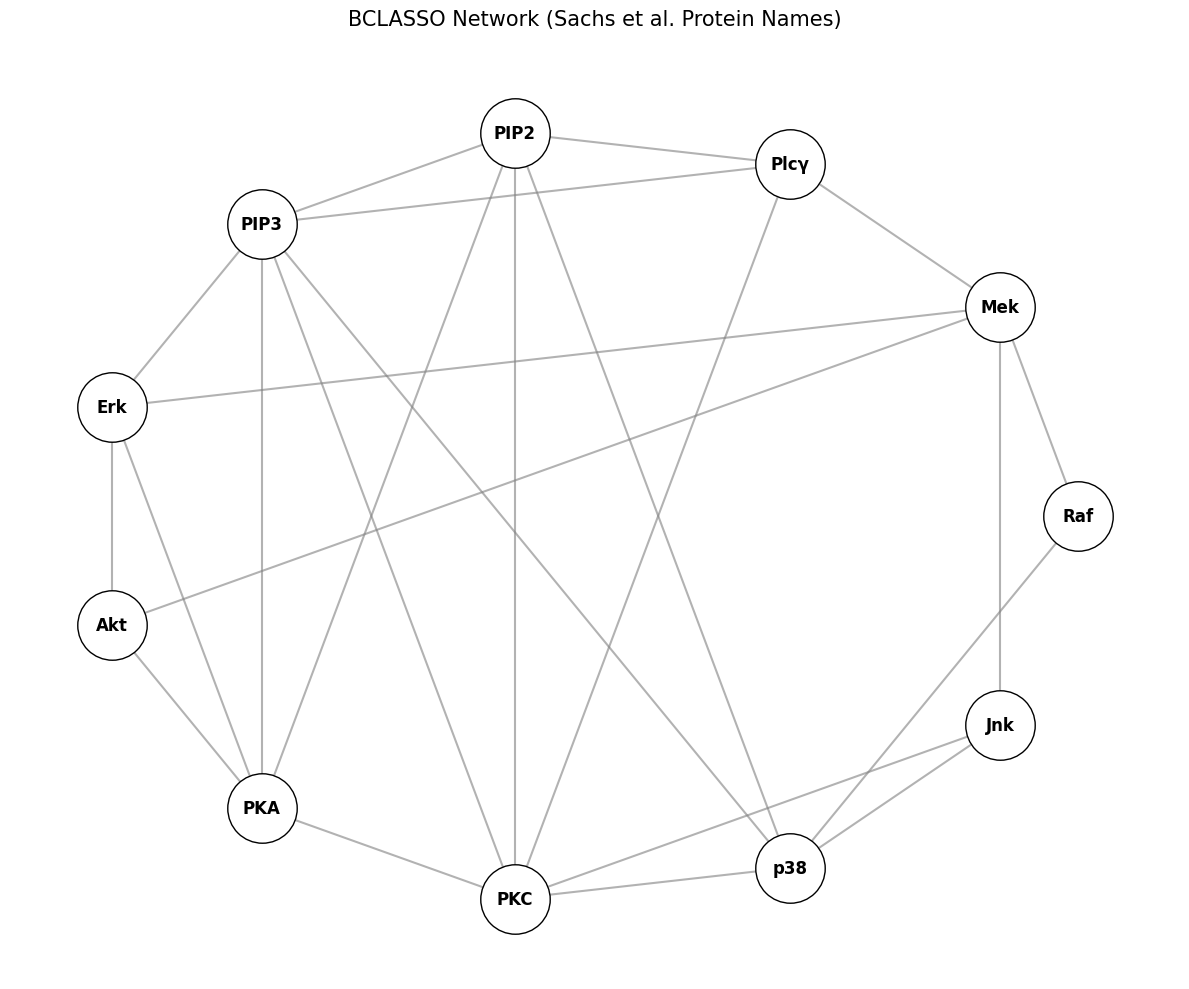

Number of connections: 24


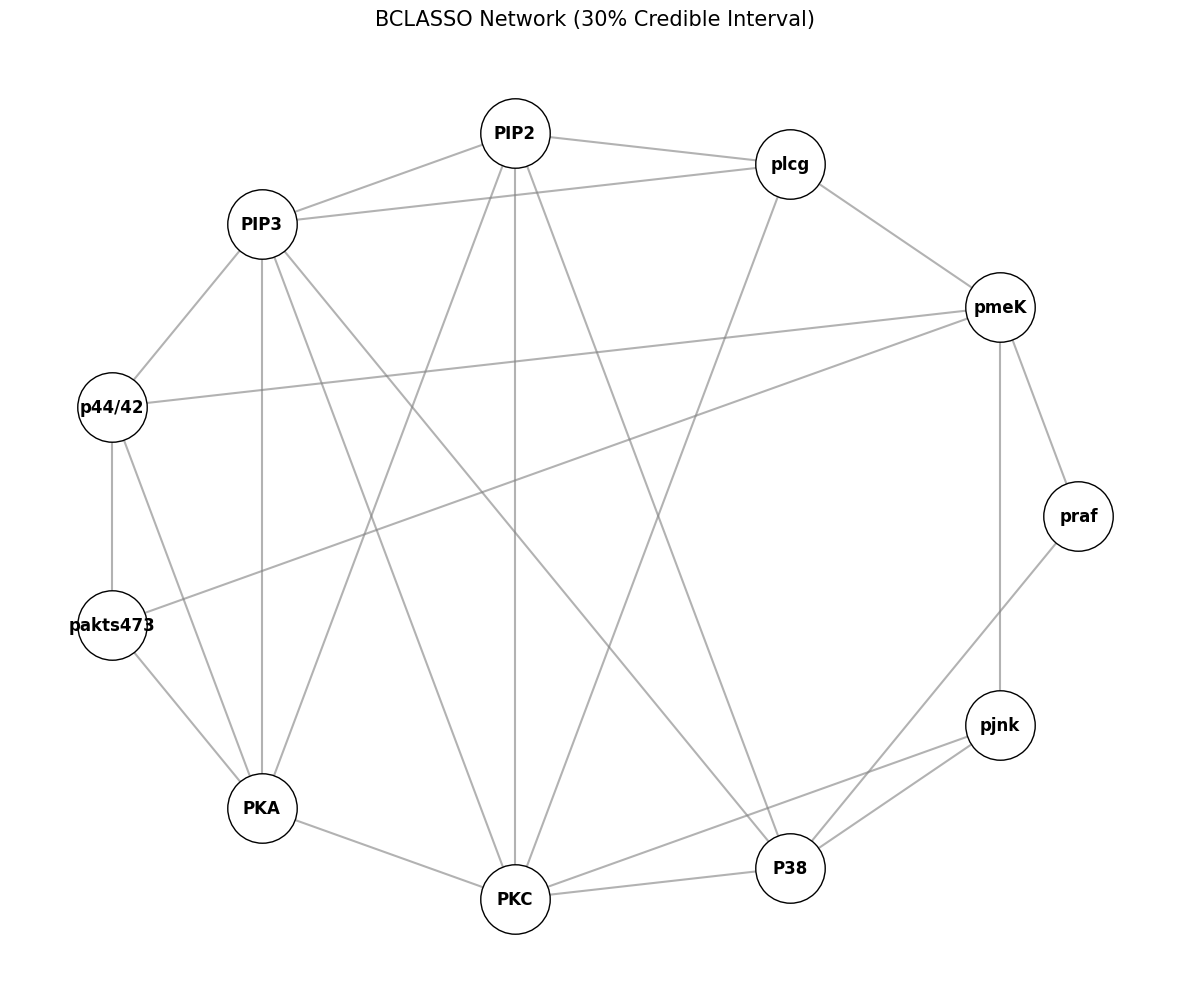

In [79]:
def plot_protein_network(Phi_sparse, protein_names, title="Bayesian Network"):
    """Построение графа взаимодействий белков"""

    # Создаём граф
    G = nx.Graph()
    d = Phi_sparse.shape[0]

    # Добавляем узлы
    G.add_nodes_from(protein_names)

    # Добавляем рёбра для ненулевых partial correlations
    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > 1e-6:  # ненулевая связь
                G.add_edge(protein_names[i], protein_names[j])

    print(f"Number of connections: {G.number_of_edges()}")

    # Визуализация
    plt.figure(figsize=(12, 10))
    pos = nx.circular_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color='white',
                           edgecolors='black', node_size=2500)

    # Отрисовка подписей
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Отрисовка ребер (сделаем их чуть тоньше и серыми)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, width=1.5)

    plt.title(title, pad=20, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G

# Белки в правильном порядке (как в данных)
protein_names = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

# Белки в правильном порядке, но с названиями как в статье
protein_names_article = [
    'Raf', 'Mek', 'Plcγ', 'PIP2', 'PIP3', 'Erk',
    'Akt', 'PKA', 'PKC', 'p38', 'Jnk'
]

# Вызов функции с новыми именами
G = plot_protein_network(
    results['Phi_sparse'],
    protein_names_article,
    title="BCLASSO Network (Sachs et al. Protein Names)"
)

# Строим сеть
G = plot_protein_network(results['Phi_sparse'], protein_names,
                         title="BCLASSO Network (30% Credible Interval)")

In [80]:
true_edges = {
    ('praf', 'pmeK'),
    ('pmeK', 'p44/42'),
    ('plcg', 'PIP2'),
    ('plcg', 'PIP3'),
    ('PIP2', 'PKC'),
    ('PIP3', 'pakts473'),
    ('PKC', 'praf'),
    ('PKC', 'P38'),
    ('PKC', 'pjnk'),
    ('PKA', 'praf'),
    ('PKA', 'pmeK'),
    ('PKA', 'p44/42'),
    ('PKA', 'akt'),        # pakts473
}

In [81]:
true_edges_undirected = {tuple(sorted(e)) for e in true_edges}

In [82]:
def get_predicted_edges(Phi_sparse, protein_names, threshold=1e-6):
    edges = set()
    d = len(protein_names)

    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > threshold:
                a, b = protein_names[i], protein_names[j]
                edges.add(tuple(sorted((a, b))))

    return edges

In [83]:
def evaluate_network(pred_edges, true_edges):
    tp = len(pred_edges & true_edges)
    fp = len(pred_edges - true_edges)
    fn = len(true_edges - pred_edges)

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    return {
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [84]:
pred_edges = get_predicted_edges(results['Phi_sparse'], protein_names)

metrics = evaluate_network(pred_edges, true_edges_undirected)

print("=== Evaluation ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

=== Evaluation ===
TP: 8
FP: 16
FN: 5
precision: 0.3333333333333333
recall: 0.6153846153846154
f1: 0.43243243243243246
